# Audio Baseline — KNN on MFCC Features

**Project:** Avis — Agentic AI Birdfeeder  
**Course:** CS 450 Introduction to AI, SDSU Spring 2026  
**Phase:** 3 — Baseline Models  
**PR:** #13 `feature/phase-3-audio-baseline`

## Goal

Establish the audio classification performance floor using a K-Nearest Neighbors (KNN)
classifier on MFCC (Mel-Frequency Cepstral Coefficient) features extracted from raw WAV files.

This is the required course baseline before pretrained models (BirdNET, Phase 4) are introduced.
Results from this notebook set the bar that BirdNET fine-tuning must beat.

## Why MFCC for KNN?

The mel spectrogram pipeline (`src/audio/preprocess.py`) produces a `(128, time_frames)` 2-D array
with variable width — recording lengths differ across species. KNN requires fixed-length feature
vectors. MFCCs solve this cleanly:

- Computed directly from raw WAV via librosa (same `sample_rate=48000` as the main pipeline)
- Summary statistics (mean + std across time) collapse variable-length audio into a fixed `(2 × n_mfcc,)` vector
- Standard practice for traditional ML audio baselines
- Fast to compute, interpretable, well-understood

## Thin-Data Species Warning

Five species have very few audio files in the dataset. Their per-class metrics
will be unreliable and should be interpreted with caution:

| Species | Train files | Val files | Test files |
|---------|-------------|-----------|------------|
| BLPH    | 1           | 1         | 1          |
| DOWO    | 3           | 1         | 1          |
| MODO    | 3           | 1         | 1          |
| ANHU    | 8           | 3         | 2          |
| YRUM    | 4           | 1         | 1          |

These species are included in the baseline run for completeness.
Low per-class F1 for these species is expected and noted — it is a data
limitation, not a model failure. The BirdNET fine-tuning phase (Phase 4)
will benefit from data augmentation strategies for thin-data species.

## 1. Imports and Configuration

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

# ── Project root on sys.path ─────────────────────────────────────────────────
# Ensures src/ imports work when notebook is run from notebooks/ or project root.
PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\Miki\Desktop\Kane\GithubRepositories\avis-birdfeeder-pr1-scaffold\avis-birdfeeder


In [2]:
# ── Load configs ─────────────────────────────────────────────────────────────
with open(PROJECT_ROOT / "configs" / "thresholds.yaml") as f:
    thresholds = yaml.safe_load(f)

with open(PROJECT_ROOT / "configs" / "paths.yaml") as f:
    paths_cfg = yaml.safe_load(f)

# Audio preprocessing parameters — match src/audio/preprocess.py exactly
SAMPLE_RATE: int = thresholds["audio"]["sample_rate"]  # 48000

# MFCC parameters
N_MFCC: int = 40        # 40 coefficients — standard for bird audio baselines
                         # captures timbral and spectral envelope information

# Split CSV paths
SPLITS_DIR = PROJECT_ROOT / paths_cfg["datasets"].get("splits", "data/splits")
XC_RAW_DIR = PROJECT_ROOT / paths_cfg["datasets"].get("xeno_canto_raw", "data/raw/xeno_canto")

# KNN hyperparameter — tuned via val set below
K_CANDIDATES = [3, 5, 7, 9, 11]

# Thin-data species — flag in analysis, do not drop
THIN_DATA_SPECIES = {"BLPH", "DOWO", "MODO", "ANHU", "YRUM"}

print(f"Sample rate    : {SAMPLE_RATE} Hz")
print(f"MFCC coefs     : {N_MFCC}")
print(f"Splits dir     : {SPLITS_DIR}")
print(f"Audio raw dir  : {XC_RAW_DIR}")

# -- Ensure output directories exist --------------------------------
RESULTS_DIR = PROJECT_ROOT / "notebooks" /  "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENTS_CSV = RESULTS_DIR / "experiments.csv"

Sample rate    : 48000 Hz
MFCC coefs     : 40
Splits dir     : C:\Users\Miki\Desktop\Kane\GithubRepositories\avis-birdfeeder-pr1-scaffold\avis-birdfeeder\data\splits
Audio raw dir  : C:\Users\Miki\Desktop\Kane\GithubRepositories\avis-birdfeeder-pr1-scaffold\avis-birdfeeder\data\raw\xeno_canto


## 2. MFCC Feature Extraction

In [3]:
def extract_mfcc_features(wav_path: Path, sr: int = SAMPLE_RATE, n_mfcc: int = N_MFCC) -> np.ndarray:
    """
    Extract fixed-length MFCC feature vector from a WAV file.

    Strategy: compute MFCCs over the full clip, then summarise each
    coefficient track with its mean and standard deviation across time.
    This yields a (2 * n_mfcc,) vector regardless of clip duration.

    Mean captures the average spectral character of the vocalization.
    Std captures how much that character varies — important for distinguishing
    trills (high std) from sustained calls (low std).

    Args:
        wav_path: Path to WAV or MP3 audio file.
        sr:       Target sample rate (default: 48000, matches BirdNET pipeline).
        n_mfcc:   Number of MFCC coefficients (default: 40).

    Returns:
        1-D float32 array of shape (2 * n_mfcc,) = (80,).
    """
    # Load and resample — same sr as the main preprocessing pipeline
    audio, _ = librosa.load(wav_path, sr=sr, mono=True, dtype=np.float32)

    # Peak-normalize — mirrors src/audio/preprocess.normalize()
    peak = np.max(np.abs(audio))
    if peak > 1e-6:
        audio = audio / peak

    # Compute MFCCs: shape (n_mfcc, time_frames)
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)

    # Summarise across time: mean + std → shape (2 * n_mfcc,)
    mean_feats = np.mean(mfccs, axis=1)   # (n_mfcc,)
    std_feats  = np.std(mfccs, axis=1)    # (n_mfcc,)

    return np.concatenate([mean_feats, std_feats]).astype(np.float32)


# ── Sanity check on one file ──────────────────────────────────────────────────
_sample_files = list(XC_RAW_DIR.glob("*/*.mp3"))
if _sample_files:
    _feat = extract_mfcc_features(_sample_files[0])
    print(f"Feature vector shape : {_feat.shape}   (expected: ({2 * N_MFCC},))")
    print(f"Range                : [{_feat.min():.2f}, {_feat.max():.2f}]")
    print(f"Sample file          : {_sample_files[0].name}")
else:
    print("WARNING: No MP3 files found. Check XC_RAW_DIR path.")

Feature vector shape : (80,)   (expected: (80,))
Range                : [-131.58, 159.90]
Sample file          : AMCR_454607.mp3


## 3. Load Splits and Extract Features

In [4]:
def load_split(csv_path: Path) -> pd.DataFrame:
    """Load a split CSV and return rows where the audio file exists on disk."""
    df = pd.read_csv(csv_path)
    # Column is 'file_path' (absolute path from generate_splits.py)
    df["filepath"] = df["file_path"].apply(Path)
    exists = df["filepath"].apply(lambda p: p.exists())
    missing = (~exists).sum()
    if missing:
        print(f"  WARNING: {missing} files in {csv_path.name} not found on disk — skipping")
    return df[exists].reset_index(drop=True)


train_df = load_split(SPLITS_DIR / "audio_train.csv")
val_df   = load_split(SPLITS_DIR / "audio_val.csv")
test_df  = load_split(SPLITS_DIR / "audio_test.csv")

print(f"Train : {len(train_df)} files across {train_df['species_code'].nunique()} species")
print(f"Val   : {len(val_df)} files across {val_df['species_code'].nunique()} species")
print(f"Test  : {len(test_df)} files across {test_df['species_code'].nunique()} species")

Train : 251 files across 18 species
Val   : 83 files across 18 species
Test  : 86 files across 18 species


In [5]:
def extract_features_for_split(df: pd.DataFrame, split_name: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Extract MFCC features for every file in a split DataFrame.

    Returns:
        X: float32 array of shape (n_samples, 2 * N_MFCC)
        y: string array of species codes, shape (n_samples,)
    """
    X_list, y_list = [], []
    failed = 0

    for _, row in df.iterrows():
        try:
            feats = extract_mfcc_features(Path(row["filepath"]))
            X_list.append(feats)
            y_list.append(row["species_code"])
        except Exception as exc:
            failed += 1
            print(f"  WARN: failed on {Path(row['filepath']).name}: {exc}")

    X = np.vstack(X_list).astype(np.float32)
    y = np.array(y_list)
    print(f"{split_name:6s}: X={X.shape}  y={y.shape}  failed={failed}")
    return X, y


print("Extracting MFCC features — this takes ~1-2 minutes...")
X_train, y_train = extract_features_for_split(train_df, "train")
X_val,   y_val   = extract_features_for_split(val_df,   "val")
X_test,  y_test  = extract_features_for_split(test_df,  "test")
print("Done.")

Extracting MFCC features — this takes ~1-2 minutes...
train : X=(251, 80)  y=(251,)  failed=0
val   : X=(83, 80)  y=(83,)  failed=0
test  : X=(86, 80)  y=(86,)  failed=0
Done.


## 4. Feature Scaling

In [6]:
# KNN is distance-based — feature scaling is required.
# StandardScaler fits on train only; transforms val and test with the same statistics.
# Fitting on val/test would leak distribution information into the baseline.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Label encoding — KNN needs integer labels internally
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print(f"Classes ({len(le.classes_)}): {list(le.classes_)}")
print(f"Scaler mean range : [{scaler.mean_.min():.2f}, {scaler.mean_.max():.2f}]")

Classes (18): ['AMRO', 'ANHU', 'BLPH', 'DOWO', 'EUST', 'HOFI', 'HOORI', 'HOSP', 'LEGO', 'MOCH', 'MODO', 'OCWA', 'SOSP', 'SPTO', 'WBNU', 'WCSP', 'WREN', 'YRUM']
Scaler mean range : [-331.09, 68.47]


## 5. K Selection on Validation Set

  k= 3  val accuracy=0.3614
  k= 5  val accuracy=0.3253
  k= 7  val accuracy=0.3133
  k= 9  val accuracy=0.3253
  k=11  val accuracy=0.3133

Best k = 3  (val accuracy = 0.3614)


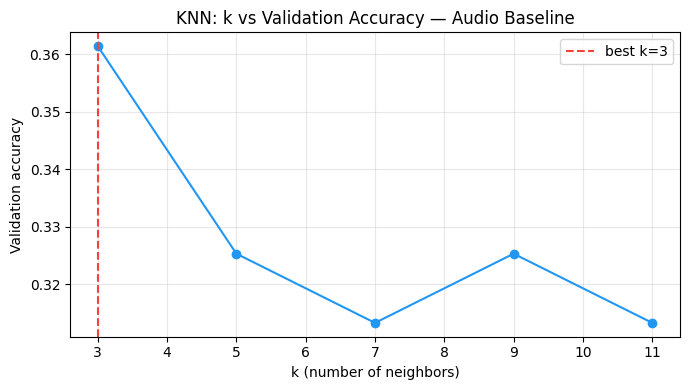

Saved: notebooks/audio_baseline_k_selection.png


In [7]:
val_scores: dict[int, float] = {}

for k in K_CANDIDATES:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    knn.fit(X_train_scaled, y_train_enc)
    acc = knn.score(X_val_scaled, y_val_enc)
    val_scores[k] = acc
    print(f"  k={k:2d}  val accuracy={acc:.4f}")

best_k = max(val_scores, key=val_scores.get)
print(f"\nBest k = {best_k}  (val accuracy = {val_scores[best_k]:.4f})")

# ── Plot k vs accuracy ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(val_scores.keys()), list(val_scores.values()), marker="o", color="#2196F3")
ax.axvline(best_k, color="#F44336", linestyle="--", label=f"best k={best_k}")
ax.set_xlabel("k (number of neighbors)")
ax.set_ylabel("Validation accuracy")
ax.set_title("KNN: k vs Validation Accuracy — Audio Baseline")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "audio_baseline_k_selection.png", dpi=120)
plt.show()
print("Saved: notebooks/audio_baseline_k_selection.png")

## 6. Train Final Model and Evaluate on Test Set

In [8]:
# Train final KNN with best k on train + val combined.
# Standard practice: once k is chosen via val set, add val data back into training
# to maximise the neighbourhood density for test evaluation.
X_trainval = np.vstack([X_train_scaled, X_val_scaled])
y_trainval  = np.concatenate([y_train_enc, y_val_enc])

knn_final = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean", n_jobs=-1)
knn_final.fit(X_trainval, y_trainval)

y_pred_enc = knn_final.predict(X_test_scaled)
y_pred     = le.inverse_transform(y_pred_enc)

test_accuracy = knn_final.score(X_test_scaled, y_test_enc)
print(f"Test accuracy (k={best_k}): {test_accuracy:.4f}")

Test accuracy (k=3): 0.3023


## 7. Per-Class Metrics

In [9]:
# Full per-class precision, recall, F1, support
report = classification_report(
    y_test, y_pred,
    labels=le.classes_,
    target_names=le.classes_,
    zero_division=0,
)
print(report)

# ── Flag thin-data species ────────────────────────────────────────────────────
print("\nNote: Metrics for thin-data species are unreliable due to small test sets.")
print("Species flagged:", sorted(THIN_DATA_SPECIES & set(le.classes_)))
print("Interpret their per-class F1 with caution — this is a data limitation,")
print("not a model failure. BirdNET fine-tuning (Phase 4) will address this.")

              precision    recall  f1-score   support

        AMRO       0.27      0.60      0.38        10
        ANHU       0.00      0.00      0.00         2
        BLPH       0.00      0.00      0.00         1
        DOWO       0.00      0.00      0.00         1
        EUST       0.14      0.33      0.20         3
        HOFI       0.50      0.60      0.55        10
       HOORI       0.00      0.00      0.00         3
        HOSP       0.00      0.00      0.00         2
        LEGO       0.25      0.14      0.18         7
        MOCH       0.00      0.00      0.00         3
        MODO       0.00      0.00      0.00         1
        OCWA       0.67      1.00      0.80         2
        SOSP       0.00      0.00      0.00         7
        SPTO       0.33      0.17      0.22         6
        WBNU       0.40      0.29      0.33         7
        WCSP       0.86      0.50      0.63        12
        WREN       0.20      0.12      0.15         8
        YRUM       0.00    

## 8. Confusion Matrix

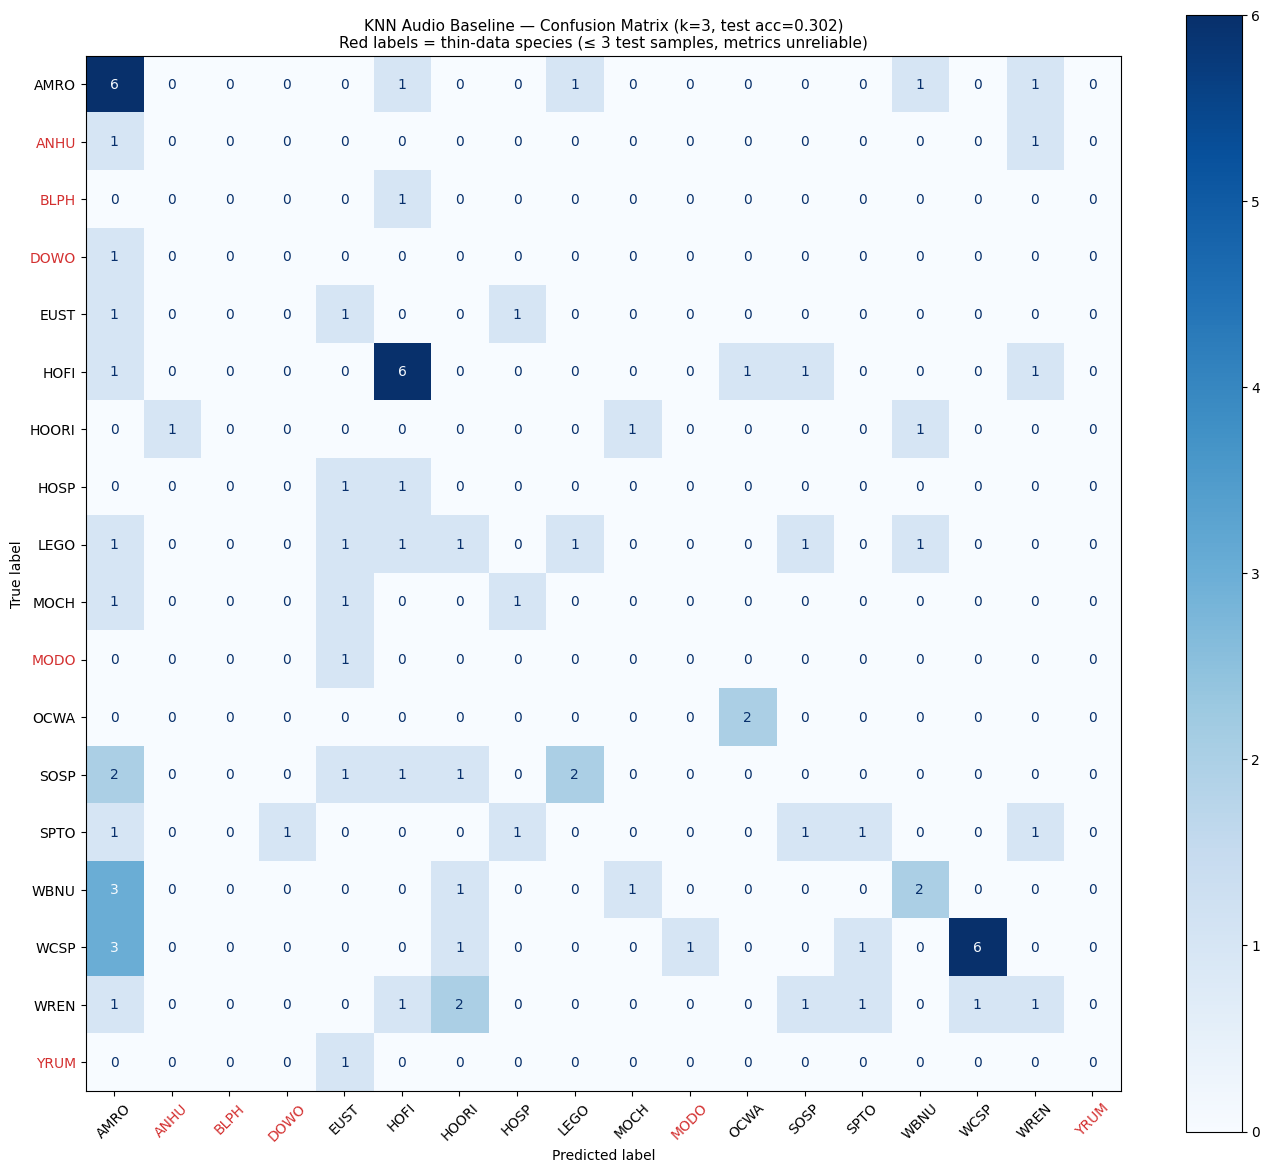

Saved: notebooks/audio_baseline_confusion_matrix.png


In [14]:
cm = confusion_matrix(y_test, y_pred, labels=le.classes_)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)

# Outline thin-data species labels in red for visibility
thin_indices = [i for i, c in enumerate(le.classes_) if c in THIN_DATA_SPECIES]
for idx in thin_indices:
    ax.get_xticklabels()[idx].set_color("#D32F2F")
    ax.get_yticklabels()[idx].set_color("#D32F2F")

ax.set_title(
    f"KNN Audio Baseline — Confusion Matrix (k={best_k}, test acc={test_accuracy:.3f})\n"
    "Red labels = thin-data species (≤ 3 test samples, metrics unreliable)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "audio_baseline_confusion_matrix.png", dpi=120)
plt.show()
print("Saved: notebooks/audio_baseline_confusion_matrix.png")

## 9. Per-Class F1 Score

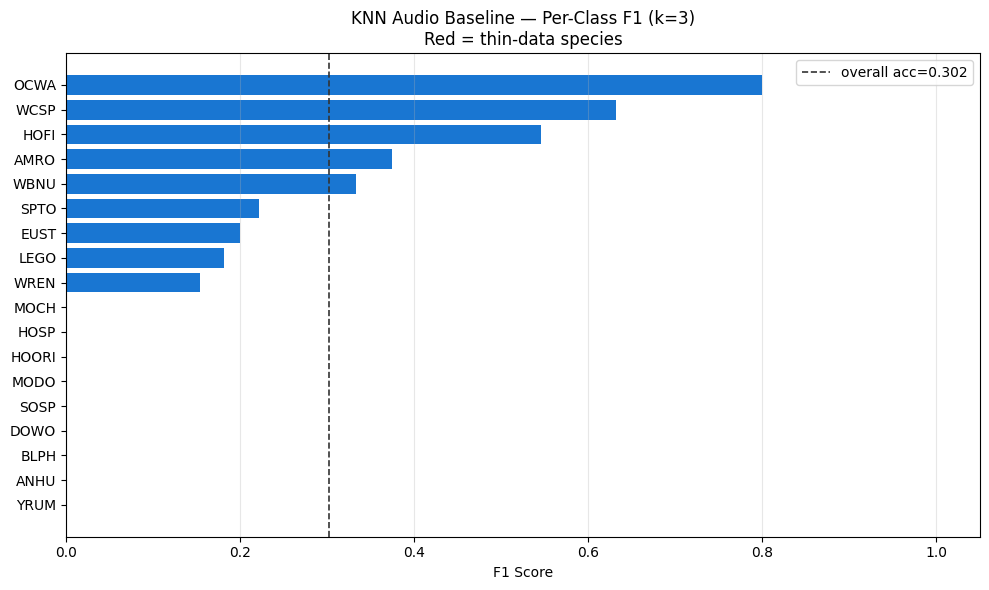

Saved: notebooks/audio_baseline_f1_per_class.png


In [11]:
from sklearn.metrics import f1_score

f1_per_class = f1_score(y_test, y_pred, labels=le.classes_, average=None, zero_division=0)
f1_df = pd.DataFrame({"species": le.classes_, "f1": f1_per_class})
f1_df = f1_df.sort_values("f1", ascending=True)

colors = ["#D32F2F" if s in THIN_DATA_SPECIES else "#1976D2" for s in f1_df["species"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(f1_df["species"], f1_df["f1"], color=colors)
ax.axvline(test_accuracy, color="#333", linestyle="--", linewidth=1.2, label=f"overall acc={test_accuracy:.3f}")
ax.set_xlabel("F1 Score")
ax.set_title(f"KNN Audio Baseline — Per-Class F1 (k={best_k})\nRed = thin-data species")
ax.set_xlim(0, 1.05)
ax.legend()
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "audio_baseline_f1_per_class.png", dpi=120)
plt.show()
print("Saved: notebooks/audio_baseline_f1_per_class.png")

## 10. Baseline Summary

In [12]:
from sklearn.metrics import f1_score as _f1

macro_f1  = _f1(y_test, y_pred, average="macro",  zero_division=0)
weighted_f1 = _f1(y_test, y_pred, average="weighted", zero_division=0)

print("=" * 55)
print("  KNN AUDIO BASELINE — FINAL RESULTS")
print("=" * 55)
print(f"  Best k                : {best_k}")
print(f"  Feature vector size   : {X_train.shape[1]}  (2 × {N_MFCC} MFCCs)")
print(f"  Train+val samples     : {len(X_trainval)}")
print(f"  Test samples          : {len(X_test)}")
print(f"  Species (test)        : {len(le.classes_)}")
print(f"  Test accuracy         : {test_accuracy:.4f}")
print(f"  Macro F1              : {macro_f1:.4f}")
print(f"  Weighted F1           : {weighted_f1:.4f}")
print("=" * 55)
print()
print("Thin-data species excluded from macro F1 interpretation:")
for sp in sorted(THIN_DATA_SPECIES & set(le.classes_)):
    sp_f1 = f1_per_class[list(le.classes_).index(sp)]
    sp_test_n = (y_test == sp).sum()
    print(f"  {sp}: F1={sp_f1:.3f}  (n_test={sp_test_n})")
print()
print("This baseline will be compared against BirdNET fine-tuning in Phase 4.")
print("Target: BirdNET macro F1 > KNN macro F1 on the same test split.")

  KNN AUDIO BASELINE — FINAL RESULTS
  Best k                : 3
  Feature vector size   : 80  (2 × 40 MFCCs)
  Train+val samples     : 334
  Test samples          : 86
  Species (test)        : 18
  Test accuracy         : 0.3023
  Macro F1              : 0.1913
  Weighted F1           : 0.2925

Thin-data species excluded from macro F1 interpretation:
  ANHU: F1=0.000  (n_test=2)
  BLPH: F1=0.000  (n_test=1)
  DOWO: F1=0.000  (n_test=1)
  MODO: F1=0.000  (n_test=1)
  YRUM: F1=0.000  (n_test=1)

This baseline will be compared against BirdNET fine-tuning in Phase 4.
Target: BirdNET macro F1 > KNN macro F1 on the same test split.


## 11. Save Baseline Model

Persist the trained KNN and scaler to `models/baselines/` so Phase 4 can
load them for direct comparison without re-running this notebook.

In [13]:
import pickle

MODELS_DIR = PROJECT_ROOT / "models" / "baselines"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

baseline_artifacts = {
    "knn": knn_final,
    "scaler": scaler,
    "label_encoder": le,
    "best_k": best_k,
    "n_mfcc": N_MFCC,
    "sample_rate": SAMPLE_RATE,
    "test_accuracy": test_accuracy,
    "macro_f1": macro_f1,
}

with open(MODELS_DIR / "audio_knn_baseline.pkl", "wb") as f:
    pickle.dump(baseline_artifacts, f)

print(f"Saved: {MODELS_DIR / 'audio_knn_baseline.pkl'}")
print("Load in Phase 4 with:")
print("  import pickle")
print("  with open('models/baselines/audio_knn_baseline.pkl', 'rb') as f:")
print("      baseline = pickle.load(f)")

Saved: C:\Users\Miki\Desktop\Kane\GithubRepositories\avis-birdfeeder-pr1-scaffold\avis-birdfeeder\models\baselines\audio_knn_baseline.pkl
Load in Phase 4 with:
  import pickle
  with open('models/baselines/audio_knn_baseline.pkl', 'rb') as f:
      baseline = pickle.load(f)


## 12. Append to Experiments Log

In [15]:
import csv
from datetime import datetime

EXPERIMENTS_CSV = RESULTS_DIR / "experiments.csv"

FIELDNAMES = [
    "phase", "notebook", "modality", "model", "features", "best_params",
    "test_accuracy", "macro_f1", "weighted_f1", "n_train", "n_test",
    "species_count", "timestamp", "notes",
]

row = {
    "phase":          "3",
    "notebook":       "audio_baseline.ipynb",
    "modality":       "audio",
    "model":          "KNN",
    "features":       f"MFCC mean+std (n_mfcc={N_MFCC}, sr={SAMPLE_RATE})",
    "best_params":    f"k={best_k}, metric=euclidean",
    "test_accuracy":  round(test_accuracy, 4),
    "macro_f1":       round(macro_f1, 4),
    "weighted_f1":    round(weighted_f1, 4),
    "n_train":        len(X_trainval),
    "n_test":         len(X_test),
    "species_count":  len(le.classes_),
    "timestamp":      datetime.now().strftime("%Y-%m-%d %H:%M"),
    "notes":          f"Thin-data species: {sorted(THIN_DATA_SPECIES & set(le.classes_))}. Baseline floor for Phase 4 BirdNET comparison.",
}

write_header = not EXPERIMENTS_CSV.exists()

with open(EXPERIMENTS_CSV, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
    if write_header:
        writer.writeheader()
    writer.writerow(row)

print(f"Appended to: {EXPERIMENTS_CSV}")

import pandas as pd
log_df = pd.read_csv(EXPERIMENTS_CSV)
print(f"\nExperiment log ({len(log_df)} run(s) total):")
display(log_df[["phase", "notebook", "modality", "model", "test_accuracy", "macro_f1", "weighted_f1", "timestamp"]])

Appended to: C:\Users\Miki\Desktop\Kane\GithubRepositories\avis-birdfeeder-pr1-scaffold\avis-birdfeeder\notebooks\results\experiments.csv

Experiment log (1 run(s) total):


,phase,notebook,modality,model,test_accuracy,macro_f1,weighted_f1,timestamp
0,3,audio_baseline.ipynb,audio,KNN,0.3023,0.1913,0.2925,2026-03-31 05:19
